In [1]:
# Cell 1: Setup, data loading and minimal baseline preparation for Task 2
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_RAW = ROOT / "data" / "raw" / "hotels.csv"
FIG_DIR = ROOT / "figures"
TAB_DIR = ROOT / "tables"
RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_RAW)

# Minimal, identical preparation for both paradigms (not the Task 4 pipeline)
TARGET = "is_canceled"
LEAKAGE = ["reservation_status", "reservation_status_date", "assigned_room_type"]
DROP = LEAKAGE + ["company"]  # company is 94.3% missing

X = df.drop(columns=DROP + [TARGET]).copy()
y = df[TARGET]

X["agent"] = X["agent"].map(lambda v: "none" if pd.isna(v) else str(int(v)))
X["children"] = X["children"].fillna(0)
X["country"] = X["country"].fillna("Unknown")

cat_cols = X.select_dtypes(exclude="number").columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"Features used : {X.shape[1]} ({len(num_cols)} numerical, {len(cat_cols)} categorical)")
print(f"Dropped       : {DROP}")
print(f"Remaining missing values: {int(X.isna().sum().sum())}")
print(f"\nTrain set: {len(X_train):,} rows | cancelled = {y_train.mean()*100:.2f}%")
print(f"Test set : {len(X_test):,} rows | cancelled = {y_test.mean()*100:.2f}%")
print(f"\nCategorical: {cat_cols}")

Features used : 27 (17 numerical, 10 categorical)
Dropped       : ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'company']
Remaining missing values: 0

Train set: 95,512 rows | cancelled = 37.04%
Test set : 23,878 rows | cancelled = 37.04%

Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'agent', 'customer_type']


In [2]:
# Cell 2: Supervised learning baselines (Table 2.1)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)


def make_preprocessor():
    """Minimal shared preprocessing: scale numbers, one-hot encode categories."""
    return ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist",
                              min_frequency=0.005), cat_cols),
    ])


models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                            random_state=RANDOM_STATE),
}

results, fitted = [], {}
for name, model in models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])

    start = time.perf_counter()
    pipe.fit(X_train, y_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    pred_time = time.perf_counter() - start

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 4),
        "Training time (s)": round(train_time, 2),
        "Prediction time (s)": round(pred_time, 2),
    })
    fitted[name] = pipe
    print(f"Finished: {name} ({train_time:.1f}s)")

table_2_1 = pd.DataFrame(results)
table_2_1.to_csv(TAB_DIR / "table2.1_supervised_results.csv", index=False)

n_encoded = len(fitted["Logistic Regression"].named_steps["prep"].get_feature_names_out())
print(f"\nEncoded feature count after one-hot encoding: {n_encoded}")
print(f"Majority-class baseline accuracy (always predict 'not cancelled'): {1 - y_test.mean():.4f}")
print("\nSupervised results on the test set:")
print(table_2_1.to_string(index=False))

Finished: Logistic Regression (2.0s)
Finished: Random Forest (31.6s)

Encoded feature count after one-hot encoding: 106
Majority-class baseline accuracy (always predict 'not cancelled'): 0.6296

Supervised results on the test set:
              Model  Accuracy  Precision  Recall  F1-score  ROC-AUC  Training time (s)  Prediction time (s)
Logistic Regression    0.8202     0.8049  0.6793    0.7368   0.9030               1.98                 0.11
      Random Forest    0.8945     0.8836  0.8239    0.8527   0.9597              31.62                 0.46


k =  2 | inertia = 2,015,489 | silhouette = 0.0697
k =  3 | inertia = 1,897,846 | silhouette = 0.0758
k =  4 | inertia = 1,805,651 | silhouette = 0.0666
k =  5 | inertia = 1,732,176 | silhouette = 0.0752
k =  6 | inertia = 1,654,065 | silhouette = 0.0822
k =  7 | inertia = 1,587,771 | silhouette = 0.0905
k =  8 | inertia = 1,535,795 | silhouette = 0.0818
k =  9 | inertia = 1,460,166 | silhouette = 0.0848
k = 10 | inertia = 1,383,106 | silhouette = 0.0956

Best k by silhouette score: 10


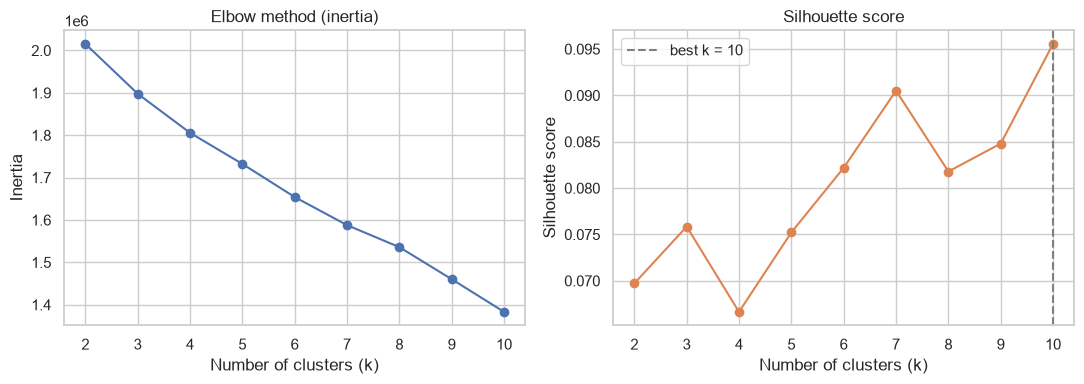


k = 2: cancellation rate within each training cluster
  Cluster 0: 47,089 bookings, 32.12% cancelled
  Cluster 1: 48,423 bookings, 41.83% cancelled

k = 10: cancellation rate within each training cluster
  Cluster 0: 22,826 bookings, 34.04% cancelled
  Cluster 1: 9,217 bookings, 34.77% cancelled
  Cluster 2: 4,921 bookings, 0.00% cancelled
  Cluster 3: 2,996 bookings, 13.89% cancelled
  Cluster 4: 24,912 bookings, 41.31% cancelled
  Cluster 5: 1,066 bookings, 54.41% cancelled
  Cluster 6: 5,726 bookings, 40.52% cancelled
  Cluster 7: 23,029 bookings, 45.83% cancelled
  Cluster 8: 710 bookings, 18.73% cancelled
  Cluster 9: 109 bookings, 100.00% cancelled

Unsupervised results on the test set:
           Model  Accuracy  F1-score     ARI    NMI  Silhouette  Training time (s)  Prediction time (s)
 K-Means (k = 2)    0.6296    0.0000  0.0087 0.0074      0.0702               0.89                 0.00
K-Means (k = 10)    0.6324    0.0415 -0.0026 0.0297      0.0940               4.87       

In [3]:
# Cell 3: Unsupervised learning with K-Means (Figure 2.1, Table 2.2)
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             normalized_mutual_info_score)

# Same preprocessing as the supervised models; labels are NOT used for fitting
prep_u = make_preprocessor()
Z_train = prep_u.fit_transform(X_train)
Z_test = prep_u.transform(X_test)

rng = np.random.default_rng(RANDOM_STATE)
sil_idx_train = rng.choice(Z_train.shape[0], size=10_000, replace=False)
sil_idx_test = rng.choice(Z_test.shape[0], size=5_000, replace=False)

# 1. Search for the number of clusters
k_values = list(range(2, 11))
inertias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(Z_train)
    inertias.append(km.inertia_)
    sil = silhouette_score(Z_train[sil_idx_train], km.labels_[sil_idx_train])
    silhouettes.append(sil)
    print(f"k = {k:2d} | inertia = {km.inertia_:,.0f} | silhouette = {sil:.4f}")

best_k = k_values[int(np.argmax(silhouettes))]
print(f"\nBest k by silhouette score: {best_k}")

# Figure 2.1: elbow and silhouette plots
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(k_values, silhouettes, marker="o", color="#DD8452")
axes[1].axvline(best_k, linestyle="--", color="grey", label=f"best k = {best_k}")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2.1_kmeans_elbow_silhouette.png", dpi=300)
plt.show()


# 2. Evaluate clusters against the true labels (labels used only for evaluation)
def evaluate_kmeans(k):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    start = time.perf_counter()
    km.fit(Z_train)
    train_time = time.perf_counter() - start

    start = time.perf_counter()
    test_clusters = km.predict(Z_test)
    pred_time = time.perf_counter() - start

    # Label each cluster by its majority class in the training data
    cluster_rate = pd.Series(y_train.values).groupby(km.labels_).mean()
    mapping = (cluster_rate >= 0.5).astype(int)
    y_pred = pd.Series(test_clusters).map(mapping).values

    print(f"\nk = {k}: cancellation rate within each training cluster")
    sizes = pd.Series(km.labels_).value_counts().sort_index()
    for c in cluster_rate.index:
        print(f"  Cluster {c}: {sizes[c]:,} bookings, {cluster_rate[c]*100:.2f}% cancelled")

    return {
        "Model": f"K-Means (k = {k})",
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "F1-score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ARI": round(adjusted_rand_score(y_test, test_clusters), 4),
        "NMI": round(normalized_mutual_info_score(y_test, test_clusters), 4),
        "Silhouette": round(silhouette_score(Z_test[sil_idx_test], test_clusters[sil_idx_test]), 4),
        "Training time (s)": round(train_time, 2),
        "Prediction time (s)": round(pred_time, 2),
    }


table_2_2 = pd.DataFrame([evaluate_kmeans(k) for k in sorted({2, best_k})])
table_2_2.to_csv(TAB_DIR / "table2.2_unsupervised_results.csv", index=False)
print("\nUnsupervised results on the test set:")
print(table_2_2.to_string(index=False))

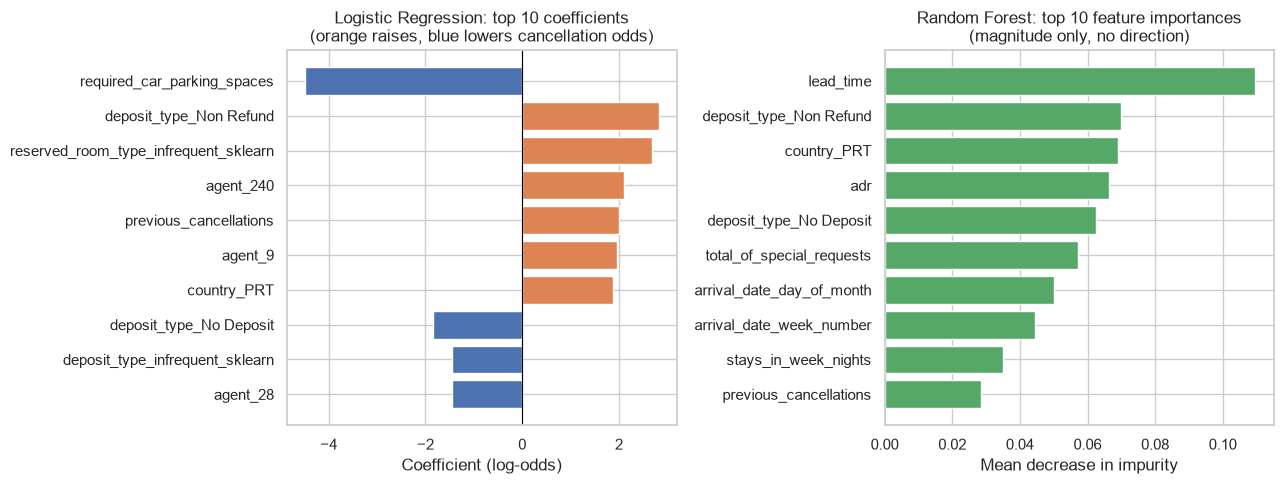

Logistic Regression: top 10 coefficients
  required_car_parking_spaces              coef = -4.493 | odds ratio = 0.01
  deposit_type_Non Refund                  coef = +2.824 | odds ratio = 16.84
  reserved_room_type_infrequent_sklearn    coef = +2.682 | odds ratio = 14.62
  agent_240                                coef = +2.097 | odds ratio = 8.14
  previous_cancellations                   coef = +2.005 | odds ratio = 7.43
  agent_9                                  coef = +1.959 | odds ratio = 7.09
  country_PRT                              coef = +1.883 | odds ratio = 6.57
  deposit_type_No Deposit                  coef = -1.841 | odds ratio = 0.16
  deposit_type_infrequent_sklearn          coef = -1.451 | odds ratio = 0.23
  agent_28                                 coef = -1.449 | odds ratio = 0.23

Random Forest: top 10 feature importances
  lead_time                                importance = 0.1097
  deposit_type_Non Refund                  importance = 0.0698
  country_PRT     

In [4]:
# Cell 4: Interpretability comparison (Figure 2.2)
def clean_names(pipe):
    """Strip the 'num__' / 'cat__' prefixes added by the ColumnTransformer."""
    return [n.split("__", 1)[1] for n in pipe.named_steps["prep"].get_feature_names_out()]

lr_pipe = fitted["Logistic Regression"]
rf_pipe = fitted["Random Forest"]

lr_coef = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=clean_names(lr_pipe))
rf_imp = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=clean_names(rf_pipe))

top_lr = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index[:10])
top_rf = rf_imp.sort_values(ascending=False).iloc[:10]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lr_colors = ["#DD8452" if v > 0 else "#4C72B0" for v in top_lr.values]
axes[0].barh(top_lr.index[::-1], top_lr.values[::-1], color=lr_colors[::-1])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Logistic Regression: top 10 coefficients\n(orange raises, blue lowers cancellation odds)")
axes[0].set_xlabel("Coefficient (log-odds)")
axes[1].barh(top_rf.index[::-1], top_rf.values[::-1], color="#55A868")
axes[1].set_title("Random Forest: top 10 feature importances\n(magnitude only, no direction)")
axes[1].set_xlabel("Mean decrease in impurity")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2.2_interpretability_comparison.png", dpi=300)
plt.show()

print("Logistic Regression: top 10 coefficients")
for feat, coef in top_lr.items():
    print(f"  {feat:40s} coef = {coef:+.3f} | odds ratio = {np.exp(coef):.2f}")

print("\nRandom Forest: top 10 feature importances")
for feat, imp in top_rf.items():
    print(f"  {feat:40s} importance = {imp:.4f}")

Finished 5% of training data (4,775 rows)
Finished 10% of training data (9,551 rows)
Finished 25% of training data (23,878 rows)
Finished 50% of training data (47,756 rows)
Finished 100% of training data (95,512 rows)


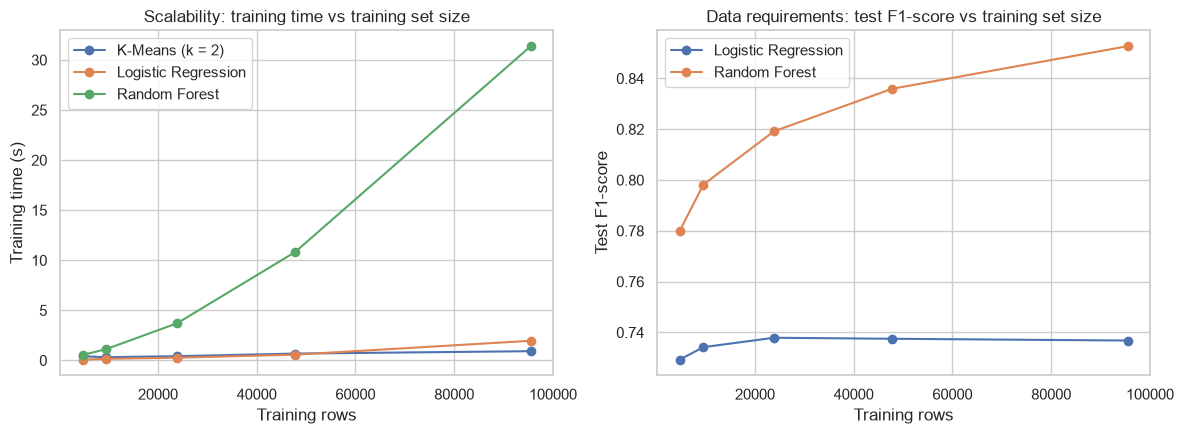


Scalability and data requirements:
              Model  Training rows  Training time (s)  Test F1-score  Test ARI
Logistic Regression           4775               0.08         0.7293       NaN
      Random Forest           4775               0.55         0.7800       NaN
    K-Means (k = 2)           4775               0.41            NaN    0.0063
Logistic Regression           9551               0.16         0.7342       NaN
      Random Forest           9551               1.13         0.7982       NaN
    K-Means (k = 2)           9551               0.32            NaN    0.0059
Logistic Regression          23878               0.27         0.7379       NaN
      Random Forest          23878               3.71         0.8192       NaN
    K-Means (k = 2)          23878               0.42            NaN    0.0072
Logistic Regression          47756               0.57         0.7375       NaN
      Random Forest          47756              10.81         0.8359       NaN
    K-Means (k =

In [5]:
# Cell 5: Scalability and data requirements (Figure 2.3, Table 2.3)
fractions = [0.05, 0.10, 0.25, 0.50, 1.00]
rows = []

for frac in fractions:
    if frac < 1:
        X_sub, _, y_sub, _ = train_test_split(
            X_train, y_train, train_size=frac, stratify=y_train, random_state=RANDOM_STATE)
    else:
        X_sub, y_sub = X_train, y_train
    n_rows = len(X_sub)

    # Supervised models
    for name, model in [
        ("Logistic Regression", LogisticRegression(max_iter=2000)),
        ("Random Forest", RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                                 random_state=RANDOM_STATE)),
    ]:
        pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
        start = time.perf_counter()
        pipe.fit(X_sub, y_sub)
        train_time = time.perf_counter() - start
        rows.append({"Model": name, "Training rows": n_rows,
                     "Training time (s)": round(train_time, 2),
                     "Test F1-score": round(f1_score(y_test, pipe.predict(X_test)), 4),
                     "Test ARI": np.nan})

    # Unsupervised model (labels not used for fitting)
    prep_k = make_preprocessor()
    Z_sub = prep_k.fit_transform(X_sub)
    km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)
    start = time.perf_counter()
    km.fit(Z_sub)
    train_time = time.perf_counter() - start
    rows.append({"Model": "K-Means (k = 2)", "Training rows": n_rows,
                 "Training time (s)": round(train_time, 2),
                 "Test F1-score": np.nan,
                 "Test ARI": round(adjusted_rand_score(y_test, km.predict(prep_k.transform(X_test))), 4)})
    print(f"Finished {frac:.0%} of training data ({n_rows:,} rows)")

table_2_3 = pd.DataFrame(rows)
table_2_3.to_csv(TAB_DIR / "table2.3_scalability_data_requirements.csv", index=False)

# Figure 2.3: training time and F1-score against training set size
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, grp in table_2_3.groupby("Model"):
    axes[0].plot(grp["Training rows"], grp["Training time (s)"], marker="o", label=name)
axes[0].set_title("Scalability: training time vs training set size")
axes[0].set_xlabel("Training rows")
axes[0].set_ylabel("Training time (s)")
axes[0].legend()

sup = table_2_3[table_2_3["Model"] != "K-Means (k = 2)"]
for name, grp in sup.groupby("Model"):
    axes[1].plot(grp["Training rows"], grp["Test F1-score"], marker="o", label=name)
axes[1].set_title("Data requirements: test F1-score vs training set size")
axes[1].set_xlabel("Training rows")
axes[1].set_ylabel("Test F1-score")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2.3_scalability_data_requirements.png", dpi=300)
plt.show()

print("\nScalability and data requirements:")
print(table_2_3.to_string(index=False))

In [6]:
# Cell 6: Summary comparison table (Table 2.4)
table_2_4 = pd.DataFrame([
    ("Learning mechanism",
     "Learns a mapping from features to observed labels by minimising prediction loss",
     "Discovers structure from feature similarity alone, e.g. minimising within-cluster distance"),
    ("Label dependency",
     "Requires labels; is_canceled is available for all 119,390 bookings",
     "Ignores labels; discards the most informative variable"),
    ("Data requirements",
     "LR saturates by about 5,000 rows (F1 0.729 to 0.737); RF keeps improving (F1 0.780 to 0.853)",
     "ARI stays at 0.006 to 0.009 regardless of data size"),
    ("Scalability",
     "LR roughly linear (0.08 to 1.96 s); RF faster than linear (0.55 to 31.38 s)",
     "K-Means under 1 s at all sizes"),
    ("Computational complexity",
     "LR: O(n x d) per iteration; RF: O(T x n log n x m) for T trees and m candidate features",
     "K-Means: O(n x k x d x i) for i iterations"),
    ("Interpretability",
     "LR gives direction and odds ratios; RF gives importance magnitude only",
     "Clusters describable as segments but not tied to cancellation"),
    ("Advantages",
     "Directly optimises the business target; strong performance (RF ROC-AUC 0.960)",
     "No labelling cost; reveals customer segments (e.g. 0% and 100% cancellation clusters)"),
    ("Limitations",
     "Risk of leakage and overfitting; RF less transparent and costlier to train",
     "Silhouette below 0.10; accuracy equals baseline; Euclidean distance suits mixed data poorly"),
    ("Suitable algorithms",
     "Logistic Regression, Random Forest, gradient boosting",
     "K-Means, K-Prototypes for mixed data"),
], columns=["Criterion", "Supervised learning", "Unsupervised learning"])

table_2_4.to_csv(TAB_DIR / "table2.4_paradigm_summary.csv", index=False)
print(f"Saved Table 2.4 with {len(table_2_4)} rows")

Saved Table 2.4 with 9 rows
